In [ ]:
import os
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive/TA_KIM/data')
dir = os.getcwd()
beta = f'{dir}/beta_p56_01_noppi.txt'
ph = f'{dir}/ph_label_universal.txt'

X_df = pd.read_csv(beta, delimiter=' ')
y_df = pd.read_csv(ph, delimiter=' ')

y_df['Sample_Name']

Mounted at /content/drive


0      TCGA-BC-A10Q-11A
1      TCGA-BC-A10R-11A
2      TCGA-BC-A10T-11A
3      TCGA-BC-A10U-11A
4      TCGA-BC-A10W-11A
             ...       
428    TCGA-UB-A7MC-01A
429    TCGA-UB-A7MD-01A
430    TCGA-WX-AA44-01A
431    TCGA-XR-A8TD-01A
432    TCGA-YA-A8S7-01A
Name: Sample_Name, Length: 433, dtype: object

In [ ]:
import pandas as pd
from sklearn.utils import resample
# Assuming X_df and y_df are your dataframes
# X_df: DataFrame with your features
# y_df: DataFrame with 'Sample_Name' and 'label'

# Merge the features and labels
df = pd.concat([X_df, y_df], axis=1)

# Function to undersample each class with a fixed random state
def undersample_class(data, label_column, sample_size=50, random_state=42):
    undersampled_data = data.groupby(label_column, group_keys=False).apply(
        lambda x: x if len(x) <= sample_size else x.sample(sample_size, random_state=random_state)
    )
    return undersampled_data

# Apply undersampling
undersampled_df = undersample_class(df, 'label', sample_size=50, random_state=42)

# Separate the features and labels again
X_undersampled_df = undersampled_df.drop(columns=['Sample_Name', 'label'])
y_undersampled_df = undersampled_df[['Sample_Name', 'label']]

# Display the results
print(X_undersampled_df.head())
print(y_undersampled_df.head())


       AAK1    ABCA4  ABHD12B   ABLIM1   ABLIM3    ABTB2    ACAT2    ACBD5  \
83  0.07810  0.92305  0.17788  0.93283  0.96948  0.14041  0.14811  0.03885   
53  0.05690  0.87603  0.20542  0.89705  0.95130  0.03867  0.01595  0.02961   
70  0.04463  0.92614  0.31151  0.94304  0.97975  0.06218  0.04632  0.02596   
45  0.03699  0.92995  0.31743  0.96008  0.94392  0.02708  0.00820  0.02220   
44  0.03271  0.87050  0.41565  0.94106  0.90883  0.02722  0.01116  0.02074   

      ACOX3    ACSL3  ...   ZNF696   ZNF700   ZNF738   ZNF790   ZNF862  \
83  0.57425  0.88939  ...  0.23550  0.02515  0.95465  0.03442  0.14973   
53  0.80691  0.85706  ...  0.15537  0.01991  0.94430  0.02876  0.15558   
70  0.71056  0.85313  ...  0.18296  0.02283  0.97364  0.02531  0.18818   
45  0.76607  0.85204  ...  0.15271  0.01696  0.97452  0.01375  0.11101   
44  0.74089  0.75026  ...  0.14947  0.01510  0.96094  0.02280  0.07984   

      ZNRF1     ZPBP  ZSCAN12L1  ZSCAN18  ZSCAN22  
83  0.25036  0.45576    0.24546  0

In [ ]:
hipo = pd.read_csv(f'{dir}/hipo_g3.txt')
hiper = pd.read_csv(f'{dir}/hiper_g3.txt')

In [ ]:
import copy

def filter_genes(X_undersampled_df, genes):
    # Extract the gene names from the genes Series
    filter_genes = genes.tolist()
    print("Filtering genes:", filter_genes)
    # Filter the columns in X_undersampled_df based on the gene names
    filtered_X_undersampled_df = X_undersampled_df.loc[:, filter_genes]
    print("Filtered DataFrame:")
    print(filtered_X_undersampled_df)
    return filtered_X_undersampled_df



In [ ]:
import copy
# Create a deep copy of X_undersampled_df
X_hipo = copy.deepcopy(X_undersampled_df)

# Apply the filter_genes function using hipo['Genes']
X_hipo = filter_genes(X_hipo, hipo['Genes'])

X_hipo

Filtering genes: ['NCOA6', 'ATPGD1', 'CDC42SE2', 'LOC100128675', 'MGC13005', 'TRAF2', 'FGL1', 'POLR2D', 'CBY3', 'NAPSB', 'AQP10', 'MRPS23', 'CCL28', 'NUMA1', 'DBF4B', 'ARAP1', 'ACOX3', 'BLVRA', 'S100A2', 'FOXP1', 'MELK', 'DEGS1', 'E2F6', 'NSUN4', 'PPP2R5A', 'ENO1', 'NOLC1', 'SEPT8', 'GPD1L', 'RBM47', 'SNHG9', 'SLC2A8', 'DDR1', 'YWHAZ', 'IVD', 'KIFC3', 'C1orf77', 'SNORD30', 'NEDD1', 'CORO1C', 'PGCP', 'C17orf90', 'CLCC1', 'ACSL3', 'HMGN3', 'SNX27', 'E2F2', 'LOC84931', 'SPG7', 'BAT1', 'MUC13', 'LOC648691', 'KCNQ1OT1', 'MYH10', 'C16orf81', 'CHMP4C', 'INADL', 'KIAA1712', 'C17orf85', 'RABIF', 'TMEM55B', 'LASP1', 'URB2', 'HNRNPF', 'GRPEL1', 'GALNTL4', 'OSBPL8', 'CDC42EP1', 'PDRG1', 'ATP5O', 'UBTF', 'FAM186A', 'HEG1', 'FAM195B', 'STK11IP', 'FAM84B', 'RTBDN', 'ETV2', 'PSMB8', 'C20orf29', 'DDIT3', 'ABCA4', 'KCNE4', 'DEPDC5', 'DMXL1', 'SFRS3', 'CDCA4', 'ZNF696', 'PRKAB2', 'HAPLN2', 'SPRY4', 'RPTOR', 'STAT3', 'ZMAT3', 'FGFR1OP', 'ZCCHC17', 'RCCD1', 'ZNF589', 'MGAT4A', 'EFHA1', 'PIGB', 'PRPF31', 'Z

,NCOA6,ATPGD1,CDC42SE2,LOC100128675,MGC13005,TRAF2,FGL1,POLR2D,CBY3,NAPSB,...,VPS13B,MAPRE1,ZNF302,COLEC11,ITPKB,ADORA1,NDN,SOX15,PRR13,SMPD3
83,0.41913,0.87152,0.36300,0.68823,0.67329,0.96748,0.93843,0.58849,0.95921,0.74198,...,0.04574,0.13795,0.03380,0.36894,0.26062,0.17465,0.15165,0.93030,0.01301,0.28875
53,0.50754,0.80589,0.33171,0.70025,0.63919,0.94488,0.84983,0.82824,0.95389,0.87108,...,0.03041,0.14915,0.02211,0.69828,0.43327,0.50835,0.14363,0.89856,0.04271,0.40412
70,0.47952,0.82637,0.37764,0.73160,0.62938,0.94867,0.90595,0.81531,0.96822,0.86728,...,0.02678,0.25881,0.02526,0.57004,0.34698,0.41635,0.32832,0.92573,0.01635,0.41181
45,0.39118,0.71661,0.32366,0.69433,0.66135,0.94968,0.90872,0.86832,0.95301,0.83333,...,0.01388,0.07797,0.02317,0.59081,0.15874,0.35710,0.24567,0.91047,0.02578,0.24046
44,0.41114,0.66706,0.32965,0.51461,0.61101,0.89804,0.90345,0.81898,0.97569,0.76331,...,0.01929,0.10343,0.03174,0.62867,0.36973,0.38916,0.32403,0.90041,0.01578,0.54698
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
398,0.03273,0.04619,0.23661,0.13936,0.35619,0.24437,0.45736,0.21977,0.45365,0.10476,...,0.02618,0.15940,0.03875,0.63245,0.32432,0.70452,0.88409,0.95510,0.02744,0.33909
318,0.14409,0.23565,0.22854,0.08605,0.51173,0.44085,0.61976,0.90308,0.59751,0.10756,...,0.02323,0.11261,0.02075,0.48785,0.05399,0.22130,0.14836,0.92302,0.02415,0.50210
403,0.12874,0.31331,0.26851,0.12463,0.50419,0.60091,0.78074,0.29169,0.69309,0.41415,...,0.01852,0.06378,0.02066,0.34789,0.45938,0.37325,0.38148,0.91014,0.02490,0.31141
381,0.10375,0.27469,0.18825,0.12765,0.29753,0.96173,0.80676,0.73748,0.86478,0.61340,...,0.03199,0.21665,0.03207,0.40658,0.14793,0.04719,0.05305,0.93601,0.02827,0.16993


In [ ]:
X_hiper = copy.deepcopy(X_undersampled_df)

X_hiper = filter_genes(X_hiper, hiper['Genes'])

Filtering genes: ['HOXA10', 'CYB5R2', 'HMGXB4', 'OSR2', 'ZNF232', 'RGS22', 'BMP4', 'ANG', 'PITPNM2', 'TBX15', 'LOXL3', 'DSCR6', 'SCG5', 'CDKL2', 'PITX3', 'KCNQ1', 'ZNF397OS', 'ALPL', 'LYPD3', 'ISL2', 'TBX4', 'CRYGD', 'SPAG6', 'EVX1', 'GRHL2', 'PKMYT1', 'MKNK2', 'DBNDD2', 'HOXC4', 'FAM196A', 'C2orf65', 'ZNF167', 'ST8SIA3', 'RIMS3', 'MIR1178', 'PRR23C', 'LMO3', 'C10orf28', 'HOXD4', 'STAG3', 'CRTAC1', 'GPRIN2', 'MEOX2', 'GNRH2', 'HIST2H2BA', 'LRP5L', 'OVOL1', 'RBAK', 'RAB22A', 'LRRN1', 'DUSP10', 'PRR14', 'HIST2H2BF', 'DLEU7', 'MEI1', 'VAX2', 'DSE', 'BOLL', 'CRHR2', 'DMRTA2', 'PAX6', 'LDHB', 'C12orf51', 'SIX3', 'C15orf26', 'HOXD3', 'DMRT3', 'ZPBP', 'VASH2', 'PYGO1', 'ABHD12B', 'HIST1H2BH', 'SLC25A46', 'CYP1A2', 'EXOC3L2', 'CDX2', 'GSTM5', 'RUNX3', 'USP53', 'MIR10B', 'TRPM1', 'APOL3', 'RILP', 'LIME1', 'PAPLN', 'ERRFI1', 'PRR15', 'KLHL33']
Filtered DataFrame:
      HOXA10   CYB5R2   HMGXB4     OSR2   ZNF232    RGS22     BMP4      ANG  \
83   0.38122  0.40058  0.28280  0.14407  0.13251  0.192

In [ ]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage
from sklearn.preprocessing import MinMaxScaler, StandardScaler

import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage
from sklearn.preprocessing import MinMaxScaler, StandardScaler

def create_clustered_heatmap(filtered_X_undersampled_df, y_undersampled_df, label_col='label', title='title'):
    # Normalize the data using Min-Max scaling
    scaler = MinMaxScaler()
    normalized_data = pd.DataFrame(scaler.fit_transform(filtered_X_undersampled_df),
                                   columns=filtered_X_undersampled_df.columns)

    # Combine the features and labels for clustering
    normalized_data['Label'] = y_undersampled_df[label_col].values

    # Create the linkage matrix for rows
    row_linkage = linkage(normalized_data.drop(columns='Label'), method='ward')

    # Create the linkage matrix for columns
    col_linkage = linkage(normalized_data.drop(columns='Label').T, method='ward')

    # Create a color palette for the labels
    label_mapping = {0: 'NT', 1: 'G1', 2: 'G2', 3: 'G3'}
    unique_labels = normalized_data['Label'].unique()
    colors = sns.color_palette("tab10", len(unique_labels))
    label_colors = {label: colors[i] for i, label in enumerate(unique_labels)}
    row_colors = normalized_data['Label'].map(label_colors)

    # Create the clustered heatmap
    plt.figure(figsize=(12, 10))
    g = sns.clustermap(normalized_data.drop(columns='Label'), row_linkage=row_linkage, col_linkage=col_linkage,
                       cmap='coolwarm', row_colors=row_colors, figsize=(12, 10), yticklabels=False)

    # Create a legend for the color labels
    for label in unique_labels:
        g.ax_row_dendrogram.bar(0, 0, color=label_colors[label], label=label_mapping[label], linewidth=0)
    g.ax_row_dendrogram.legend(title="Class", loc="center", ncol=1)

    # Update color bar label
    colorbar = g.ax_heatmap.collections[0].colorbar
    colorbar.set_label('MinMaxScaling')

    plt.title(title)
    plt.show()

# Example usage:
# create_clustered_heatmap(filtered_X_undersampled_df, y_undersampled_df, label_col='Class')





<Figure size 1200x1000 with 0 Axes>

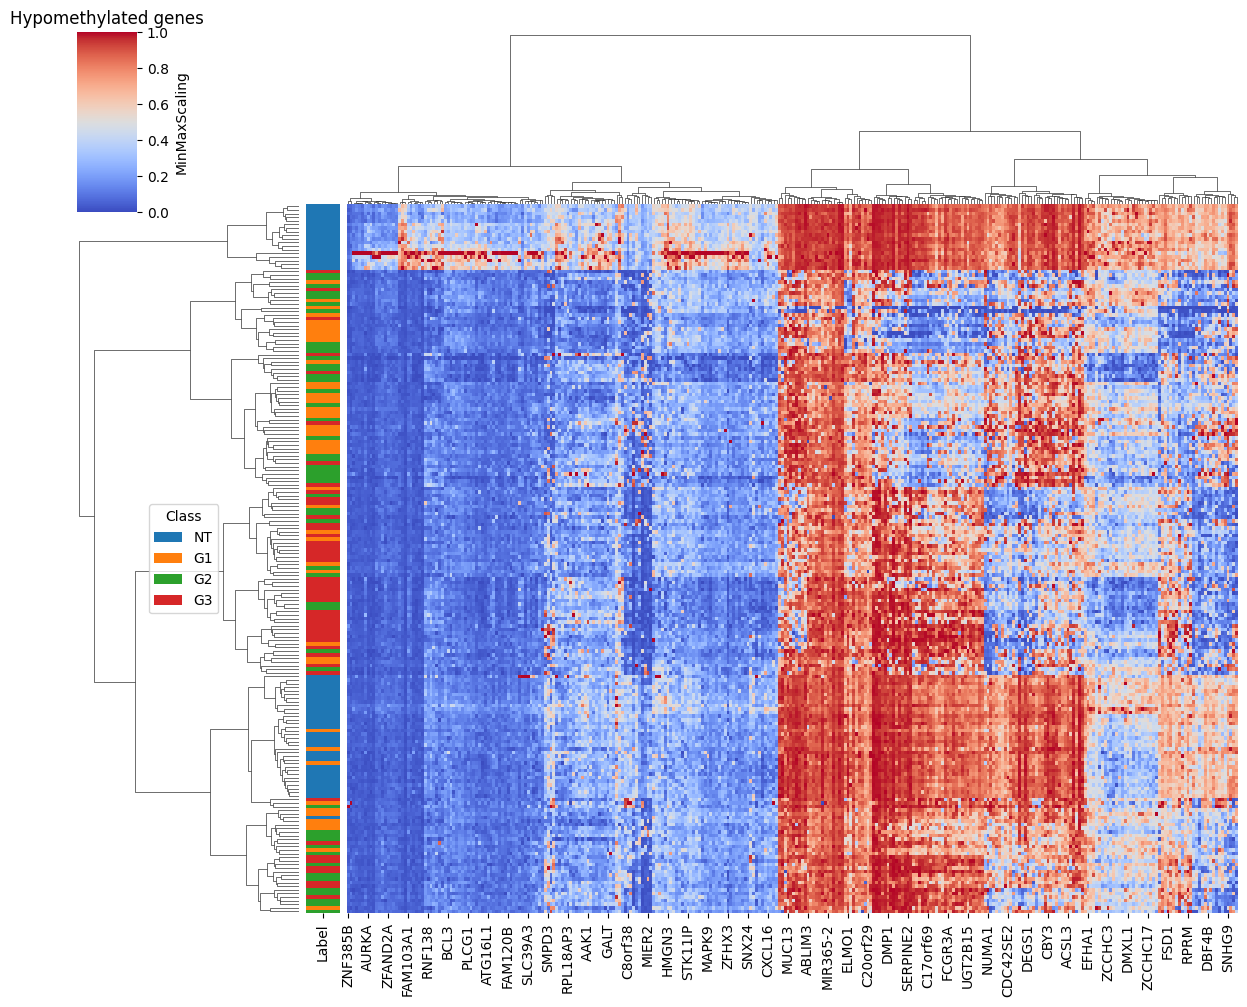

In [ ]:
# Example usage:
# filtered_X_undersampled_df and y_undersampled_df should be your actual data
create_clustered_heatmap(X_hipo, y_undersampled_df, title = 'Hypomethylated genes')

<Figure size 1200x1000 with 0 Axes>

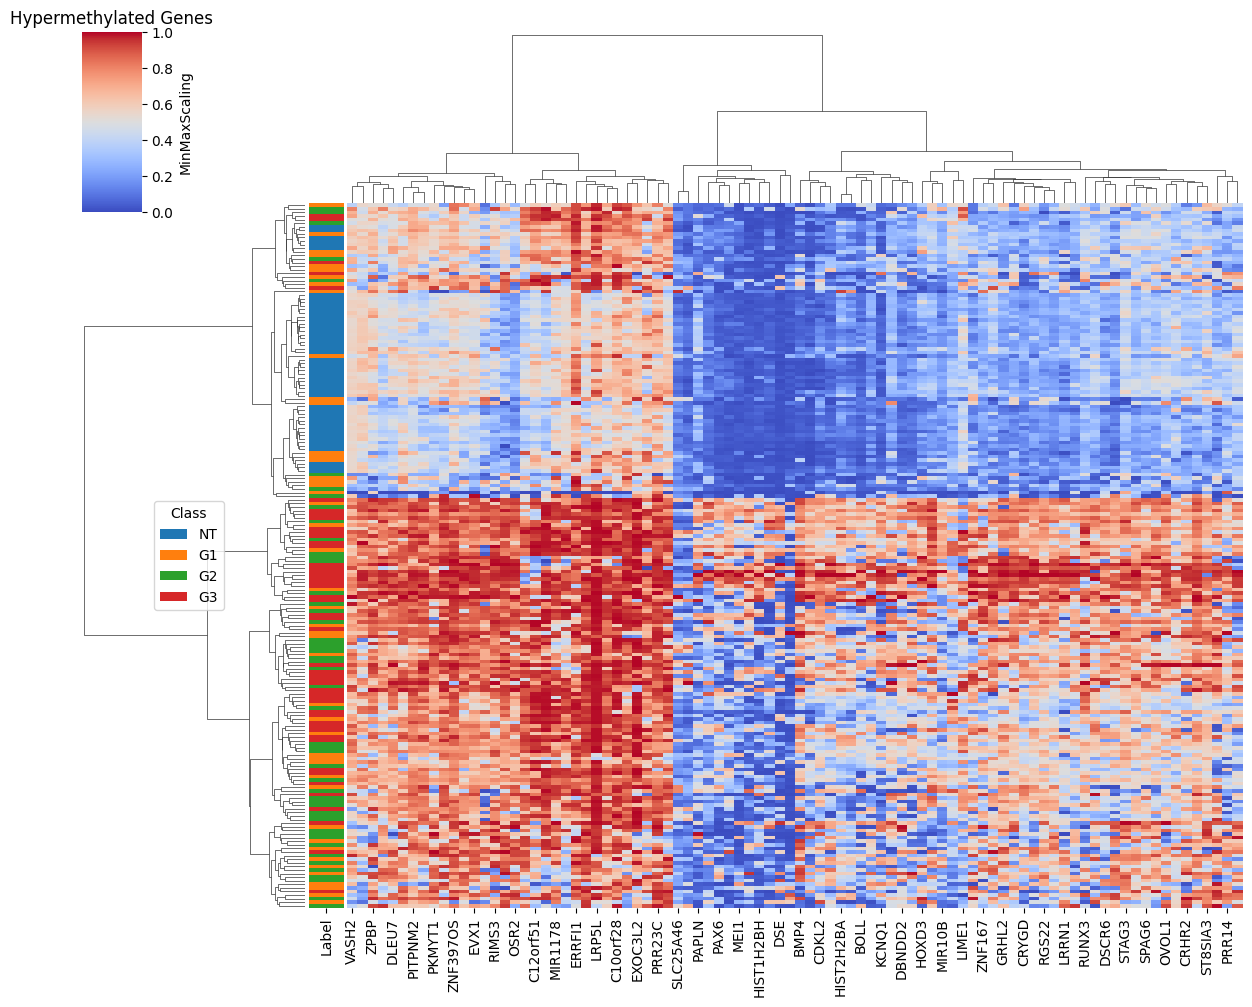

In [ ]:
# Example usage:
# filtered_X_undersampled_df and y_undersampled_df should be your actual data
create_clustered_heatmap(X_hiper, y_undersampled_df, title = 'Hypermethylated Genes')

In [ ]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage
from sklearn.preprocessing import MinMaxScaler, StandardScaler

def create_clustered_heatmap(filtered_X_undersampled_df, y_undersampled_df, label_col='label', title='title', opt=1):
    # Normalize the data using Min-Max scaling
    scaler = MinMaxScaler()
    normalized_data = pd.DataFrame(scaler.fit_transform(filtered_X_undersampled_df),
                                   columns=filtered_X_undersampled_df.columns)

    # Combine the features and labels for clustering
    normalized_data['Label'] = y_undersampled_df[label_col].values

    # Create the linkage matrix for rows
    row_linkage = linkage(normalized_data.drop(columns='Label'), method='ward')

    # Create the linkage matrix for columns
    col_linkage = linkage(normalized_data.drop(columns='Label').T, method='ward')

    # Create a color palette for the labels
    label_mapping = {0: 'NT', 1: 'G1', 2: 'G2', 3: 'G3'}
    unique_labels = normalized_data['Label'].unique()
    colors = sns.color_palette("tab10", len(unique_labels))
    label_colors = {label: colors[i] for i, label in enumerate(unique_labels)}
    row_colors = normalized_data['Label'].map(label_colors)

    # Choose color map based on the opt parameter
    if opt == 1:
        cmap = 'coolwarm'
    elif opt == 2:
        cmap = sns.color_palette("Reds", as_cmap=True)
    elif opt == 3:
        cmap = sns.color_palette("Blues_r", as_cmap=True)
    else:
        cmap = 'coolwarm'  # default to coolwarm if opt is not 1, 2, or 3

    # Create the clustered heatmap
    plt.figure(figsize=(12, 10))
    g = sns.clustermap(normalized_data.drop(columns='Label'), row_linkage=row_linkage, col_linkage=col_linkage,
                       cmap=cmap, row_colors=row_colors, figsize=(12, 10), yticklabels=False)

    # Create a legend for the color labels
    for label in unique_labels:
        g.ax_row_dendrogram.bar(0, 0, color=label_colors[label], label=label_mapping[label], linewidth=0)
    g.ax_row_dendrogram.legend(title="Class", loc="center", ncol=1)

    # Update color bar label
    colorbar = g.ax_heatmap.collections[0].colorbar
    colorbar.set_label('MinMaxScaling')

    plt.title(title)
    plt.show()


<Figure size 1200x1000 with 0 Axes>

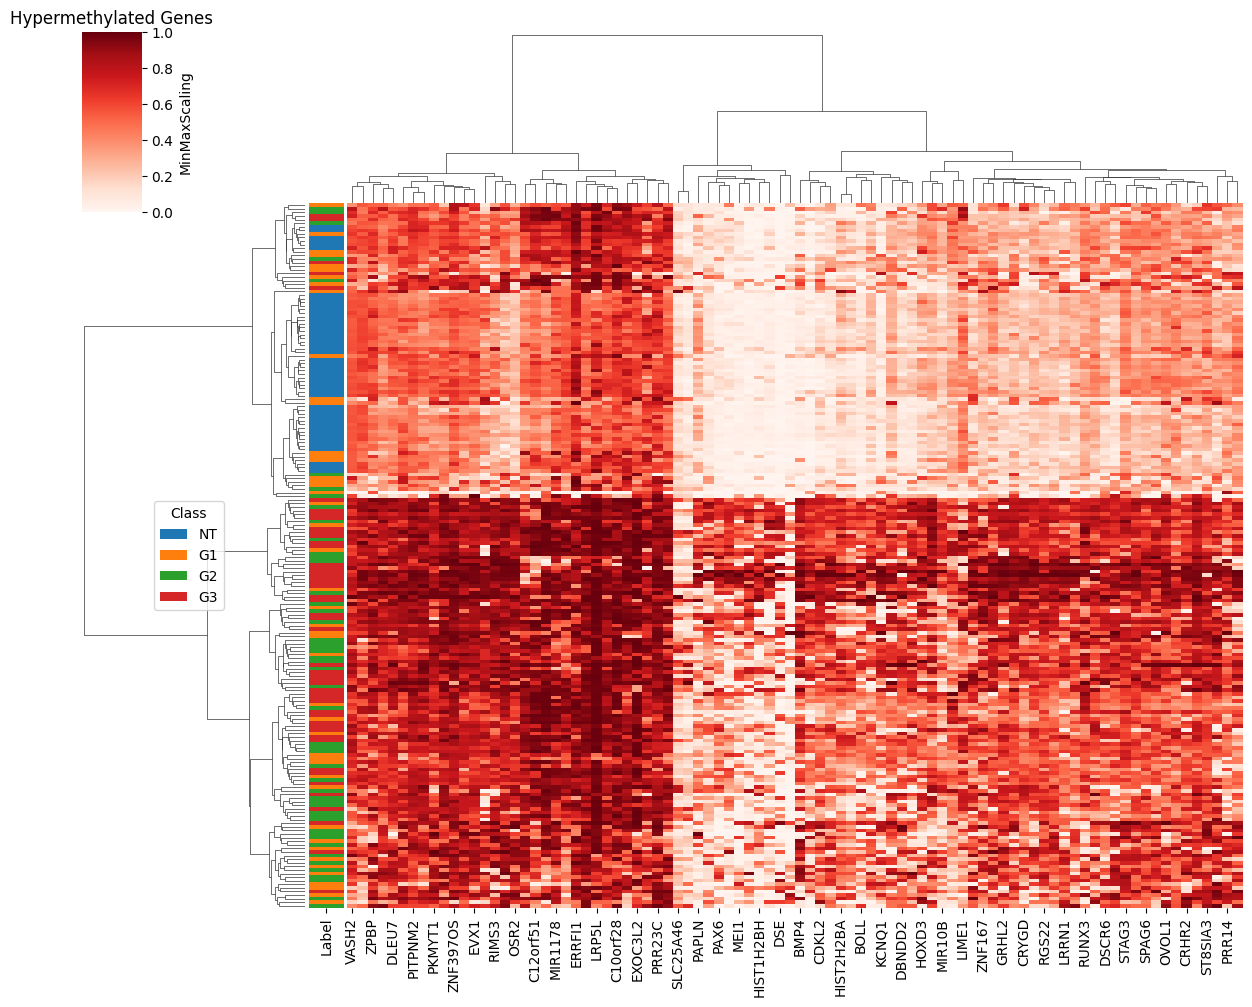

In [ ]:
# Example usage:
# filtered_X_undersampled_df and y_undersampled_df should be your actual data
create_clustered_heatmap(X_hiper, y_undersampled_df, title = 'Hypermethylated Genes', opt = 2)

<Figure size 1200x1000 with 0 Axes>

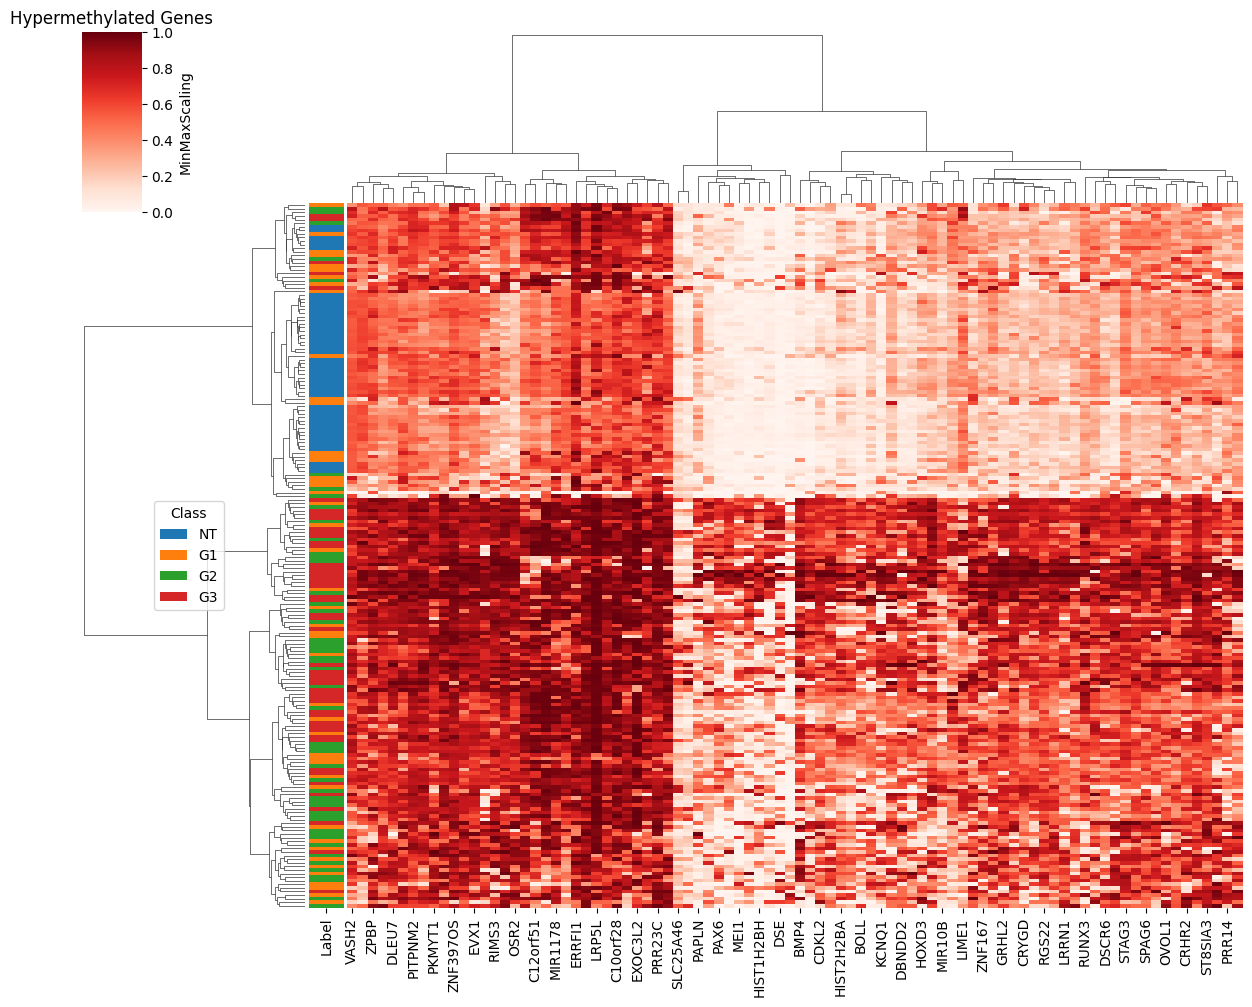

In [ ]:
# Example usage:
# filtered_X_undersampled_df and y_undersampled_df should be your actual data
create_clustered_heatmap(X_hiper, y_undersampled_df, title = 'Hypermethylated Genes', opt = 2)

<Figure size 1200x1000 with 0 Axes>

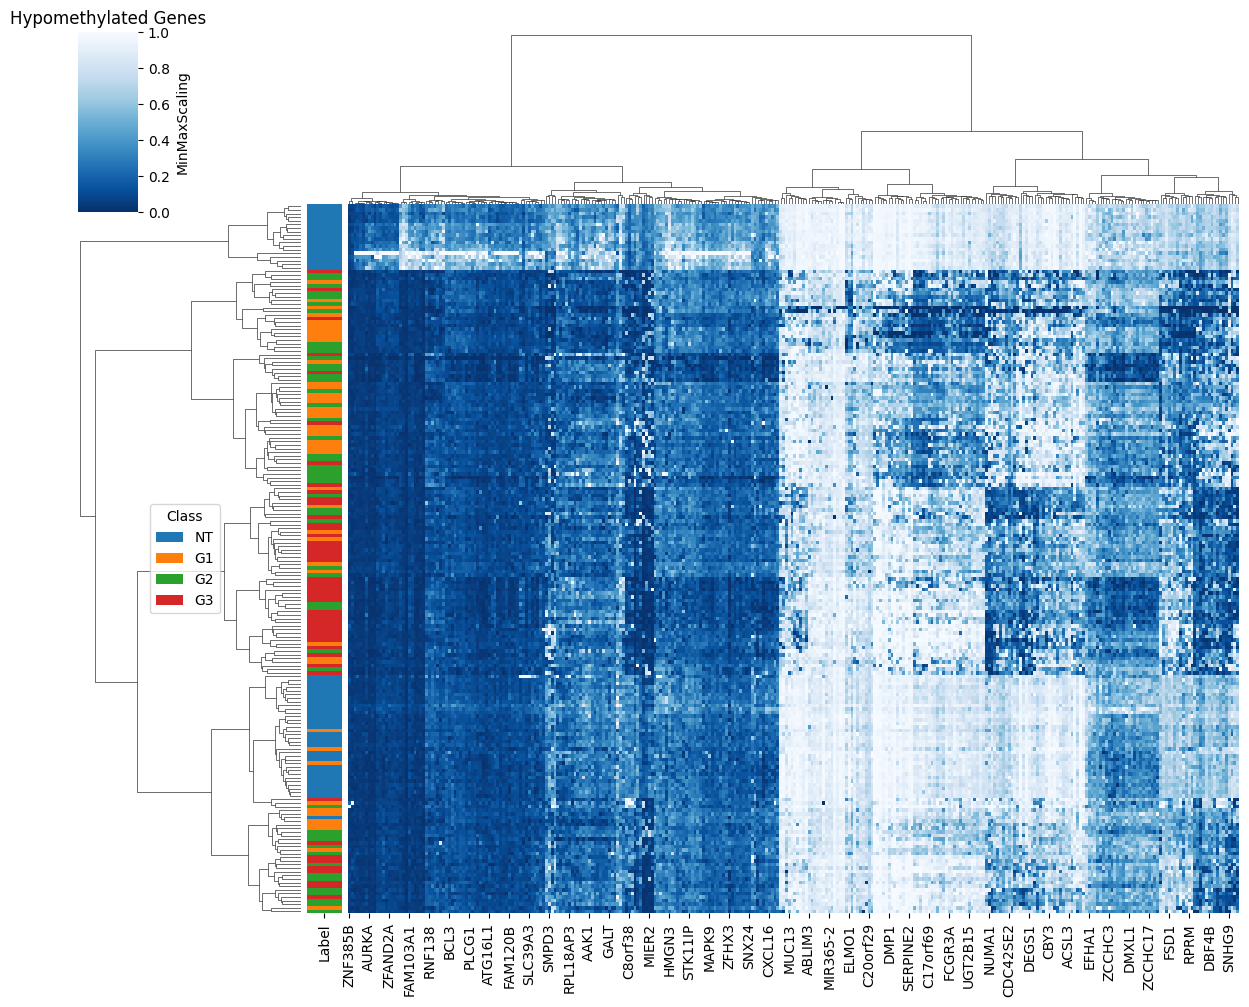

In [ ]:
# Example usage:
# filtered_X_undersampled_df and y_undersampled_df should be your actual data
create_clustered_heatmap(X_hipo, y_undersampled_df, title = 'Hypomethylated Genes', opt = 3)

In [ ]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage
from sklearn.preprocessing import MinMaxScaler

def create_clustered_heatmap_row(filtered_X_undersampled_df, y_undersampled_df, label_col='label', title='title', opt=1):
    # Normalize the data based on rows using Min-Max scaling
    scaler = MinMaxScaler()
    normalized_data = filtered_X_undersampled_df.apply(lambda x: pd.Series(scaler.fit_transform(x.values.reshape(-1, 1)).flatten()), axis=1)
    normalized_data.columns = filtered_X_undersampled_df.columns

    # Combine the features and labels for clustering
    normalized_data['Label'] = y_undersampled_df[label_col].values

    # Create the linkage matrix for rows
    row_linkage = linkage(normalized_data.drop(columns='Label'), method='ward')

    # Create the linkage matrix for columns
    col_linkage = linkage(normalized_data.drop(columns='Label').T, method='ward')

    # Create a color palette for the labels
    label_mapping = {0: 'NT', 1: 'G1', 2: 'G2', 3: 'G3'}
    unique_labels = normalized_data['Label'].unique()
    colors = sns.color_palette("tab10", len(unique_labels))
    label_colors = {label: colors[i] for i, label in enumerate(unique_labels)}
    row_colors = normalized_data['Label'].map(label_colors)

    # Choose color map based on the opt parameter
    if opt == 1:
        cmap = 'coolwarm'
    elif opt == 2:
        cmap = sns.color_palette("Reds", as_cmap=True)
    elif opt == 3:
        cmap = sns.color_palette("Blues_r", as_cmap=True)
    else:
        cmap = 'coolwarm'  # default to coolwarm if opt is not 1, 2, or 3

    # Create the clustered heatmap
    plt.figure(figsize=(12, 10))
    g = sns.clustermap(normalized_data.drop(columns='Label'), row_linkage=row_linkage, col_linkage=col_linkage,
                       cmap=cmap, row_colors=row_colors, figsize=(12, 10), yticklabels=False)

    # Create a legend for the color labels
    for label in unique_labels:
        g.ax_row_dendrogram.bar(0, 0, color=label_colors[label], label=label_mapping[label], linewidth=0)
    g.ax_row_dendrogram.legend(title="Class", loc="center", ncol=1)

    # Update color bar label
    colorbar = g.ax_heatmap.collections[0].colorbar
    colorbar.set_label('MinMaxScaling')

    plt.title(title)
    plt.show()


In [ ]:
cm = f'{dir}/CM.xlsx'
df = f'{dir}/DF.xlsx'
pro = f'{dir}/PRO.xlsx'

neg_cm = pd.read_excel(cm, sheet_name='NEG_CM')
pos_cm = pd.read_excel(cm, sheet_name='POS_CM')
cm_df = pd.read_excel(cm, sheet_name='HAKIM')

neg_df = pd.read_excel(df, sheet_name='NEG_DIFF')
pos_df = pd.read_excel(df, sheet_name='POS_DIFF')
df_df = pd.read_excel(df, sheet_name='DIFF')

neg_pro = pd.read_excel(pro, sheet_name='NEG_PRO')
pos_pro = pd.read_excel(pro, sheet_name='POS_PRO')
pro_df = pd.read_excel(pro, sheet_name='PRO')

In [ ]:
print(neg_cm)

   SYMBOL      G1      G2      G3
0    BMP4  49.303  54.549  83.836
1   CCL28 -49.353 -39.251 -64.201
2  CORO1C -23.015 -34.772 -43.159
3  DUSP10  10.199  13.827  40.371
4   HDAC2 -46.767 -25.015 -15.555
5   HMGB1  -8.824  -9.175 -17.423
6   MEOX2  23.767  25.406  45.144


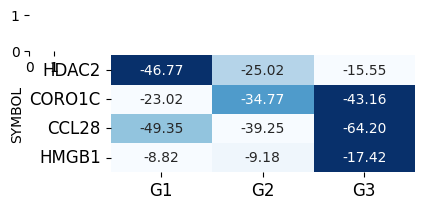

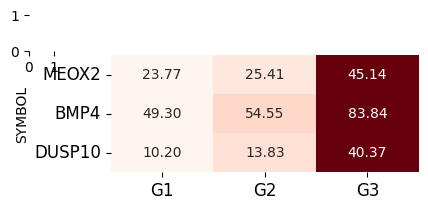

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

def normalize_rows(df):
    """
    Normalize each row of the DataFrame using Min-Max scaling.

    Parameters:
    df (pd.DataFrame): The input DataFrame.

    Returns:
    pd.DataFrame: The DataFrame with each row normalized.
    """
    scaler = MinMaxScaler()
    normalized_df = df.copy()
    normalized_values = scaler.fit_transform(df[['G1', 'G2', 'G3']].values.T).T
    normalized_df[['G1', 'G2', 'G3']] = normalized_values
    return normalized_df

def generate_heatmaps(df, figsize=(5, 2), fontsize=12):
    """
    Generate two heatmaps from a DataFrame:
    - One for the negative_df with blue-white color (1 as blue, 0 as white)
    - One for the positive_df with white-red color (0 as white, 1 as red)

    Parameters:
    df (pd.DataFrame): The input DataFrame.
    figsize (tuple): The size of the figure.
    fontsize (int): The font size of the labels.
    """
    # Separate the DataFrame
    negative_df, positive_df = separate_positive_negative(df)

    if not negative_df.empty:
        negative_normalized_df = normalize_rows(negative_df)
        negative_normalized_df.set_index('SYMBOL', inplace=True)
        negative_df.set_index('SYMBOL', inplace=True)

        # Plot heatmap for negative_df with clustering on rows only, without dendrograms
        g = sns.clustermap(
            negative_normalized_df[['G1', 'G2', 'G3']],
            cmap=sns.color_palette("Blues_r", as_cmap=True),  # Use reversed Blues colormap
            cbar=False,
            figsize=figsize,
            col_cluster=False,
            row_cluster=True,  # Enable row clustering
            annot=negative_df[['G1', 'G2', 'G3']],
            fmt='.2f'
        )

        g.ax_row_dendrogram.set_visible(False)
        g.ax_col_dendrogram.set_visible(False)
        g.ax_heatmap.yaxis.set_label_position("left")
        g.ax_heatmap.yaxis.tick_left()
        plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0, fontsize=fontsize)  # Rotate row labels to horizontal
        plt.setp(g.ax_heatmap.get_xticklabels(), fontsize=fontsize)  # Set font size for column labels
        #plt.title('Negative DataFrame Heatmap (Blue-White)')
        plt.show()

    if not positive_df.empty:
        positive_normalized_df = normalize_rows(positive_df)
        positive_normalized_df.set_index('SYMBOL', inplace=True)
        positive_df.set_index('SYMBOL', inplace=True)

        # Plot heatmap for positive_df with clustering on rows only, without dendrograms
        g = sns.clustermap(
            positive_normalized_df[['G1', 'G2', 'G3']],
            cmap='Reds',
            cbar=False,
            figsize=figsize,
            col_cluster=False,
            row_cluster=True,  # Enable row clustering
            annot=positive_df[['G1', 'G2', 'G3']],
            fmt='.2f'
        )
        g.ax_row_dendrogram.set_visible(False)
        g.ax_col_dendrogram.set_visible(False)
        g.ax_heatmap.yaxis.set_label_position("left")
        g.ax_heatmap.yaxis.tick_left()
        plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0, fontsize=fontsize)  # Rotate row labels to horizontal
        plt.setp(g.ax_heatmap.get_xticklabels(), fontsize=fontsize)  # Set font size for column labels
        #plt.title('Positive DataFrame Heatmap (White-Red)')
        plt.show()

# Assuming the separate_positive_negative function is already defined
def separate_positive_negative(df):
    """
    Separate a DataFrame into two DataFrames: one with rows containing negative values and one with rows containing only non-negative values.

    Parameters:
    df (pd.DataFrame): The input DataFrame.

    Returns:
    negative_df (pd.DataFrame): DataFrame containing rows with at least one negative value.
    positive_df (pd.DataFrame): DataFrame containing rows with only non-negative values.
    """
    negative_df = df[(df[['G1', 'G2', 'G3']] < 0).any(axis=1)]
    positive_df = df[(df[['G1', 'G2', 'G3']] >= 0).all(axis=1)]

    return negative_df, positive_df

# Example usage
data = {
    'SYMBOL': ['BMP4', 'CCL28', 'CORO1C', 'DUSP10', 'HDAC2', 'HMGB1', 'MEOX2'],
    'G1': [49.303, -49.353, -23.015, 10.199, -46.767, -8.824, 23.767],
    'G2': [54.549, -39.251, -34.772, 13.827, -25.015, -9.175, 25.406],
    'G3': [83.836, -64.201, -43.159, 40.371, -15.555, -17.423, 45.144]
}
df = pd.DataFrame(data)
generate_heatmaps(df)


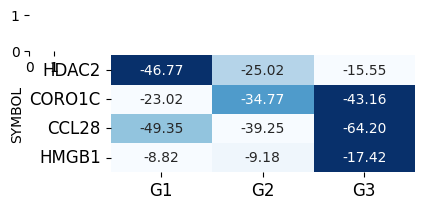

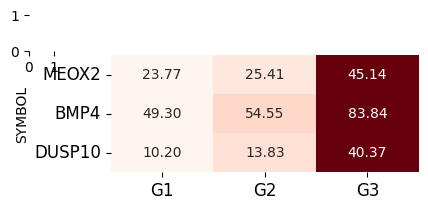

In [ ]:
generate_heatmaps(neg_cm)

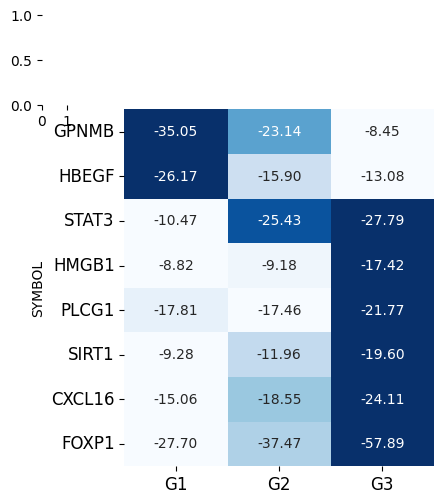

In [ ]:
generate_heatmaps(pos_cm, figsize=(5, 5))

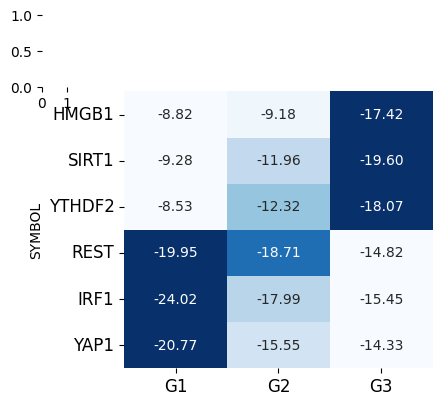

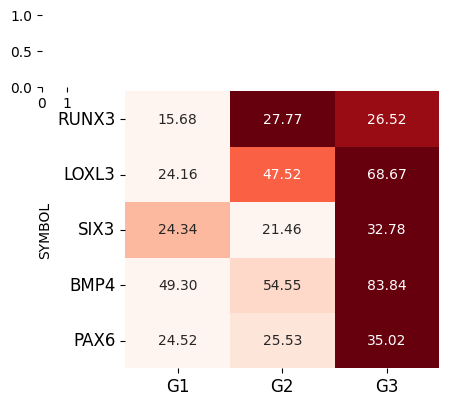

In [ ]:
generate_heatmaps(neg_df, figsize=(5, 4))



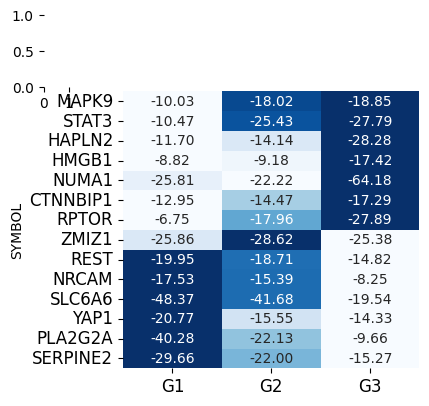

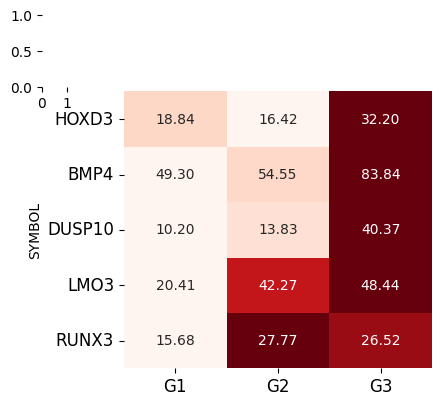

In [ ]:
generate_heatmaps(pos_df, figsize=(5, 4))



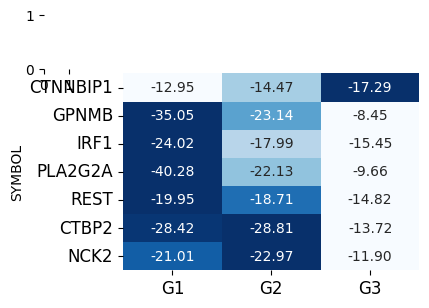

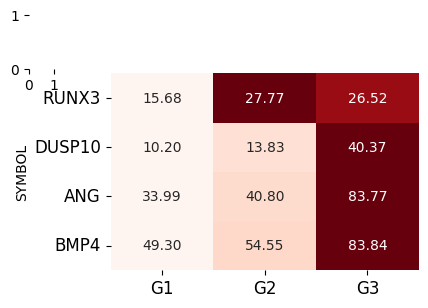

In [ ]:
generate_heatmaps(neg_pro, figsize=(5, 3))



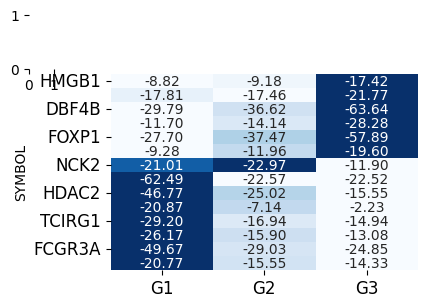

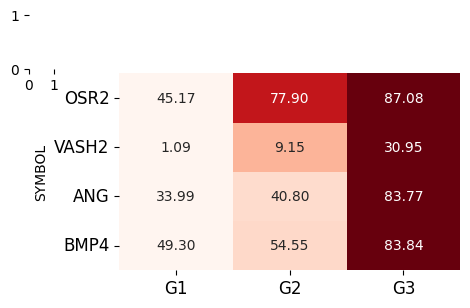

In [ ]:
generate_heatmaps(pos_pro, figsize=(5, 3))



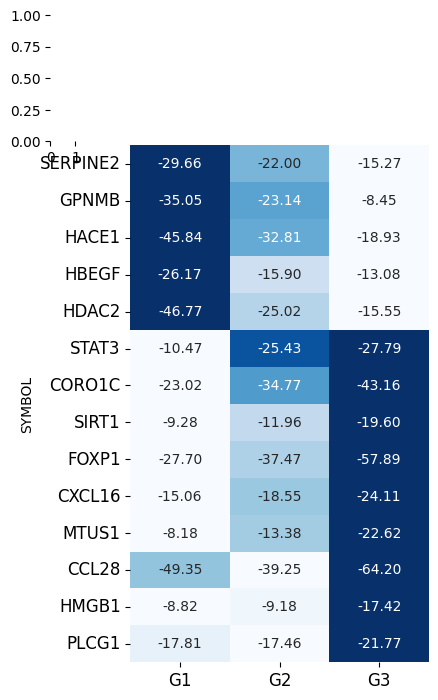

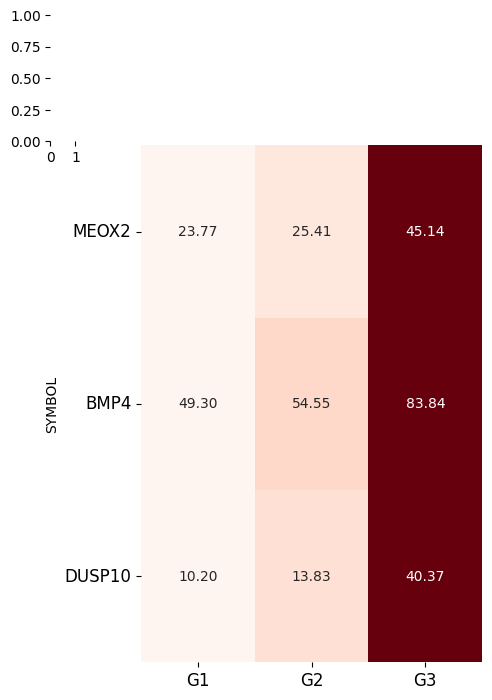

In [ ]:
generate_heatmaps(cm_df, figsize=(5,7))



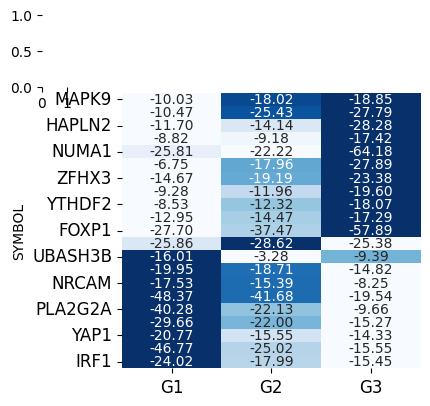

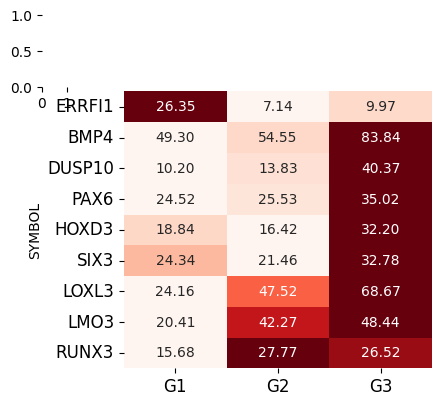

In [ ]:
generate_heatmaps(df_df, figsize=(5, 4))



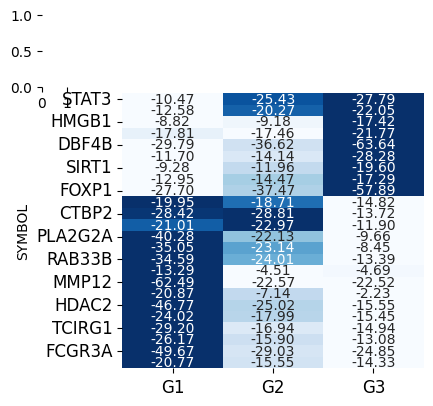

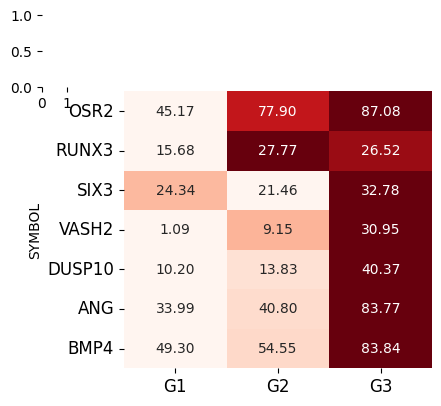

In [ ]:
generate_heatmaps(pro_df, figsize=(5, 4))



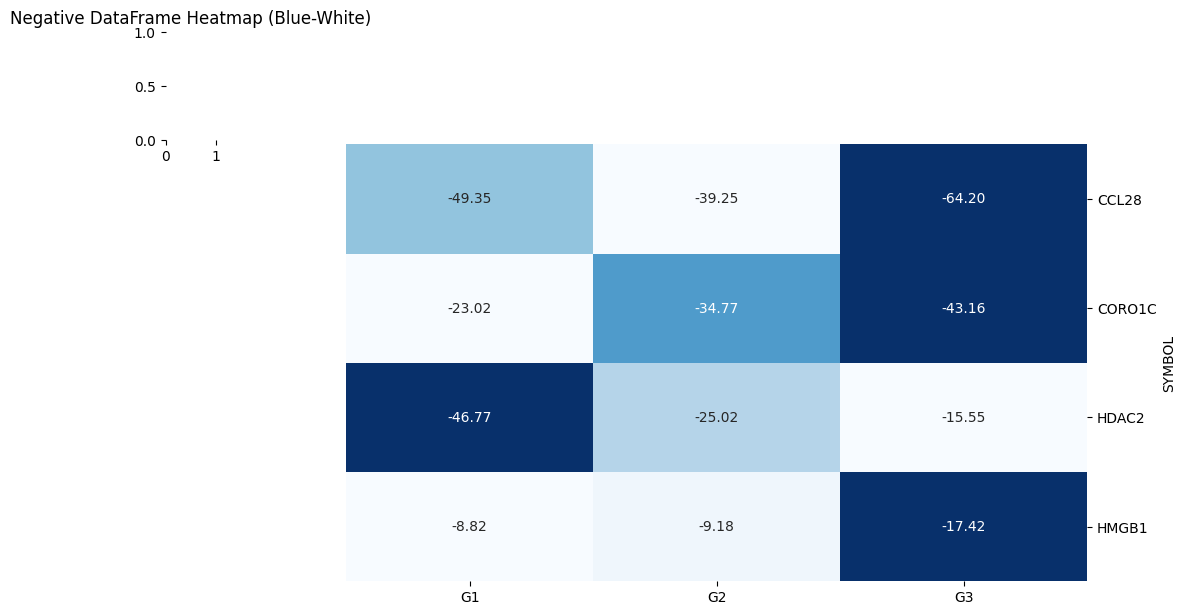

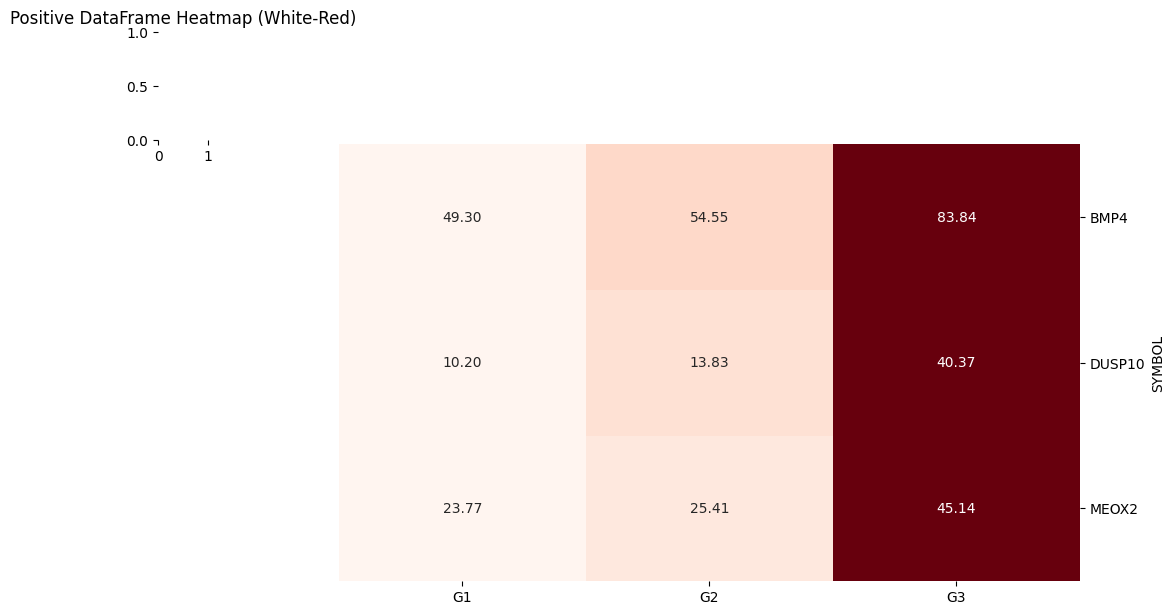

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

def normalize_rows(df):
    """
    Normalize each row of the DataFrame using Min-Max scaling.

    Parameters:
    df (pd.DataFrame): The input DataFrame.

    Returns:
    pd.DataFrame: The DataFrame with each row normalized.
    """
    scaler = MinMaxScaler()
    normalized_df = df.copy()
    normalized_values = scaler.fit_transform(df[['G1', 'G2', 'G3']].values.T).T
    normalized_df[['G1', 'G2', 'G3']] = normalized_values
    return normalized_df

def generate_heatmaps(df):
    """
    Generate two heatmaps from a DataFrame:
    - One for the negative_df with blue-white color (1 as blue, 0 as white)
    - One for the positive_df with white-red color (0 as white, 1 as red)

    Parameters:
    df (pd.DataFrame): The input DataFrame.
    """
    # Separate the DataFrame
    negative_df, positive_df = separate_positive_negative(df)

    if not negative_df.empty:
        negative_normalized_df = normalize_rows(negative_df)
        negative_normalized_df.set_index('SYMBOL', inplace=True)
        negative_df.set_index('SYMBOL', inplace=True)

        # Plot heatmap for negative_df with clustering on rows only, without dendrograms
        g = sns.clustermap(
            negative_normalized_df[['G1', 'G2', 'G3']],
            cmap=sns.color_palette("Blues_r", as_cmap=True),  # Use reversed Blues colormap
            cbar=False,
            figsize=(10, 6),
            col_cluster=False,
            row_cluster=False,
            annot=negative_df[['G1', 'G2', 'G3']],
            fmt='.2f'
        )
        g.ax_row_dendrogram.set_visible(False)
        g.ax_col_dendrogram.set_visible(False)
        plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0)  # Rotate row labels to horizontal
        plt.title('Negative DataFrame Heatmap (Blue-White)')
        plt.show()


    if not positive_df.empty:
        positive_normalized_df = normalize_rows(positive_df)
        positive_normalized_df.set_index('SYMBOL', inplace=True)
        positive_df.set_index('SYMBOL', inplace=True)

        # Plot heatmap for positive_df with clustering on rows only, without dendrograms
        g = sns.clustermap(
            positive_normalized_df[['G1', 'G2', 'G3']],
            cmap='Reds',
            cbar=False,
            figsize=(10, 6),
            col_cluster=False,
            row_cluster=False,
            annot=positive_df[['G1', 'G2', 'G3']],
            fmt='.2f'
        )
        g.ax_row_dendrogram.set_visible(False)
        g.ax_col_dendrogram.set_visible(False)
        plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0)  # Rotate row labels to horizontal
        plt.title('Positive DataFrame Heatmap (White-Red)')
        plt.show()

# Assuming the separate_positive_negative function is already defined
def separate_positive_negative(df):
    """
    Separate a DataFrame into two DataFrames: one with rows containing negative values and one with rows containing only non-negative values.

    Parameters:
    df (pd.DataFrame): The input DataFrame.

    Returns:
    negative_df (pd.DataFrame): DataFrame containing rows with at least one negative value.
    positive_df (pd.DataFrame): DataFrame containing rows with only non-negative values.
    """
    negative_df = df[(df[['G1', 'G2', 'G3']] < 0).any(axis=1)]
    positive_df = df[(df[['G1', 'G2', 'G3']] >= 0).all(axis=1)]

    return negative_df, positive_df

# Example usage
data = {
    'SYMBOL': ['BMP4', 'CCL28', 'CORO1C', 'DUSP10', 'HDAC2', 'HMGB1', 'MEOX2'],
    'G1': [49.303, -49.353, -23.015, 10.199, -46.767, -8.824, 23.767],
    'G2': [54.549, -39.251, -34.772, 13.827, -25.015, -9.175, 25.406],
    'G3': [83.836, -64.201, -43.159, 40.371, -15.555, -17.423, 45.144]
}
df = pd.DataFrame(data)
generate_heatmaps(df)


In [ ]:
generate_heatmaps(neg_cm)

ValueError: Columns must be same length as key

In [ ]:
neg_neg_cm, pos_neg_cm = separate_positive_negative(neg_cm)

,SYMBOL,G1,G2,G3
1,CCL28,-49.353,-39.251,-64.201
2,CORO1C,-23.015,-34.772,-43.159
4,HDAC2,-46.767,-25.015,-15.555
5,HMGB1,-8.824,-9.175,-17.423


/usr/local/lib/python3.10/dist-packages/seaborn/matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
/usr/local/lib/python3.10/dist-packages/seaborn/matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)
<ipython-input-10-876aa3856f69>:47: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  fig.colorbar(sm, orientation='vertical')


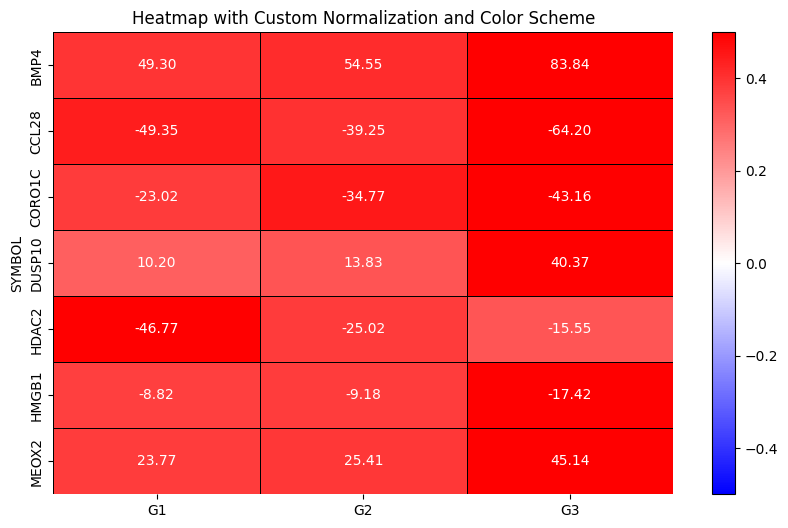

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
df = pd.DataFrame(neg_cm)


# Set 'SYMBOL' column as the index
df.set_index('SYMBOL', inplace=True)

# Normalize the data to [-0.5, 0.5]
def normalize(row):
    if np.all(row >= 0):
        return 0.5 * row / row.max()
    elif np.all(row <= 0):
        return 0.5 * row / row.min()
    else:
        raise ValueError("Row contains both positive and negative values.")

normalized_df = df.apply(normalize, axis=1)

# Create custom colormaps
neg_cmap = LinearSegmentedColormap.from_list('neg_cmap', ['blue', 'white'])
pos_cmap = LinearSegmentedColormap.from_list('pos_cmap', ['white', 'red'])

# Separate positive and negative values
neg_values = normalized_df.copy()
neg_values[neg_values > 0] = np.nan

pos_values = normalized_df.copy()
pos_values[pos_values < 0] = np.nan

# Plot heatmap
fig, ax = plt.subplots(figsize=(10, 6))

# Plot negative values
sns.heatmap(neg_values, cmap=neg_cmap, center=0, cbar=False, ax=ax, linewidths=0.5, linecolor='black', annot=df, fmt=".2f")

# Plot positive values
sns.heatmap(pos_values, cmap=pos_cmap, center=0, cbar=False, ax=ax, linewidths=0.5, linecolor='black', annot=df, fmt=".2f")

# Add colorbar
norm = plt.Normalize(-0.5, 0.5)
sm = plt.cm.ScalarMappable(cmap=LinearSegmentedColormap.from_list('combined_cmap', ['blue', 'white', 'red']), norm=norm)
sm.set_array([])
fig.colorbar(sm, orientation='vertical')

plt.title('Heatmap with Custom Normalization and Color Scheme')
plt.show()